In [1]:
import numpy as np
import matplotlib.pyplot as plt

import torch
from torch.utils.data import TensorDataset, DataLoader
import torch.nn as nn
import torch.optim as optim
import torch.nn.utils as utils

import torch.fft
from typing import Callable, List, Union    

In [2]:
features_path = "data/friction_data/features_AgingLaw_v2.csv"
targets_path = "data/friction_data/targets_AgingLaw_v2.csv"
train_samples = 700

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:
def x_log_transform(x):
    return torch.log(torch.log(1/x))

def x_state_transform(x: np.array) -> torch.Tensor:
    return torch.Tensor(np.sqrt(np.log(1e8*x)))

def x_heal_transform(x: np.array) -> torch.Tensor:
    return (torch.abs(torch.Tensor(x) - 1e-8) < 1e-12).float()

In [4]:
feature = torch.Tensor(np.genfromtxt(features_path, delimiter=',')[:, np.newaxis, :])
target = torch.Tensor(np.genfromtxt(targets_path, delimiter=',')[:, np.newaxis, :])

train_x = feature[:train_samples, :, :]
train_y = target[:train_samples, :, :]
test_x = feature[train_samples:, :, :]
test_y = target[train_samples:, :, :]

C:\Users\mathi\AppData\Local\Temp\ipykernel_7520\3468790013.py:2: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  bins = np.logspace(np.log10(feature.min()), np.log10(feature.max()), 100)


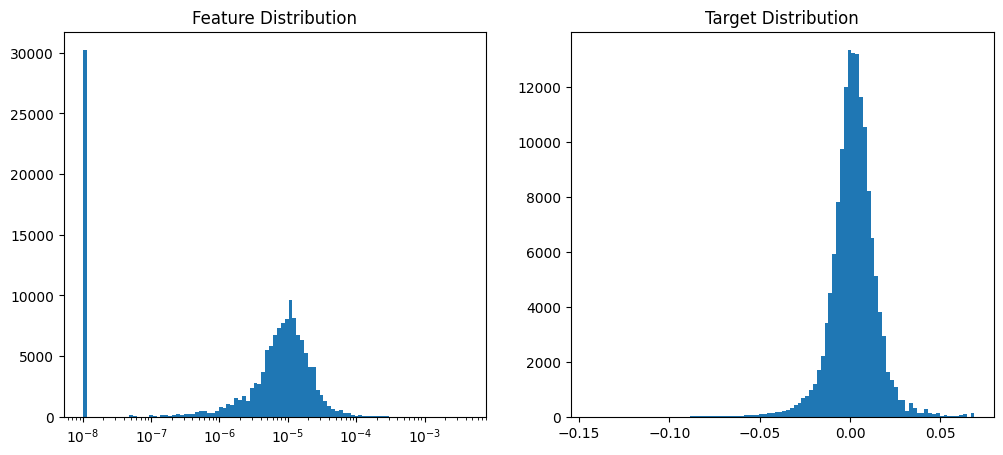

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
bins = np.logspace(np.log10(feature.min()), np.log10(feature.max()), 100)
axes[0].hist(feature.flatten(), bins=bins)
axes[0].set_xscale('log')
axes[0].set_title("Feature Distribution")
axes[1].hist(target.flatten(), bins=100)
axes[1].set_title("Target Distribution")
plt.show()


In [6]:

train_x_norm_state = x_state_transform(train_x)
x_max = train_x_norm_state.max()
train_x_norm_state /= x_max 
test_x_norm_state = x_state_transform(test_x) / x_max

train_x_norm_heal = x_heal_transform(train_x)
test_x_norm_heal = x_heal_transform(test_x)

train_x_norm = torch.cat([train_x_norm_state, train_x_norm_heal], dim=1)
test_x_norm = torch.cat([test_x_norm_state, test_x_norm_heal], dim=1)

train_y_norm = train_y / train_y.max()
test_y_norm = test_y / train_y.max()

train_dataset = TensorDataset(train_x_norm, train_y_norm)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

test_dataset = TensorDataset(test_x_norm, test_y_norm)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)


C:\Users\mathi\AppData\Local\Temp\ipykernel_7520\3656093467.py:5: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  return torch.Tensor(np.sqrt(np.log(1e8*x)))


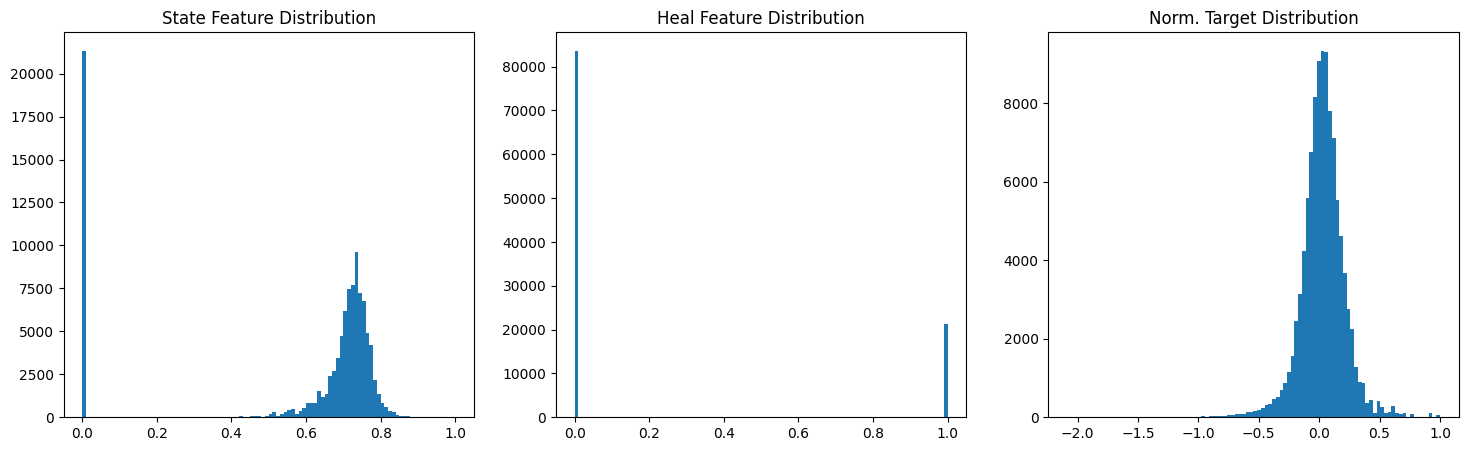

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].hist(train_x_norm_state.flatten(), bins=100)
axes[0].set_title("State Feature Distribution")

axes[1].hist(train_x_norm_heal.flatten(), bins=100)
axes[1].set_title("Heal Feature Distribution")

axes[2].hist(train_y_norm.flatten(), bins=100)
axes[2].set_title("Norm. Target Distribution")
plt.show()


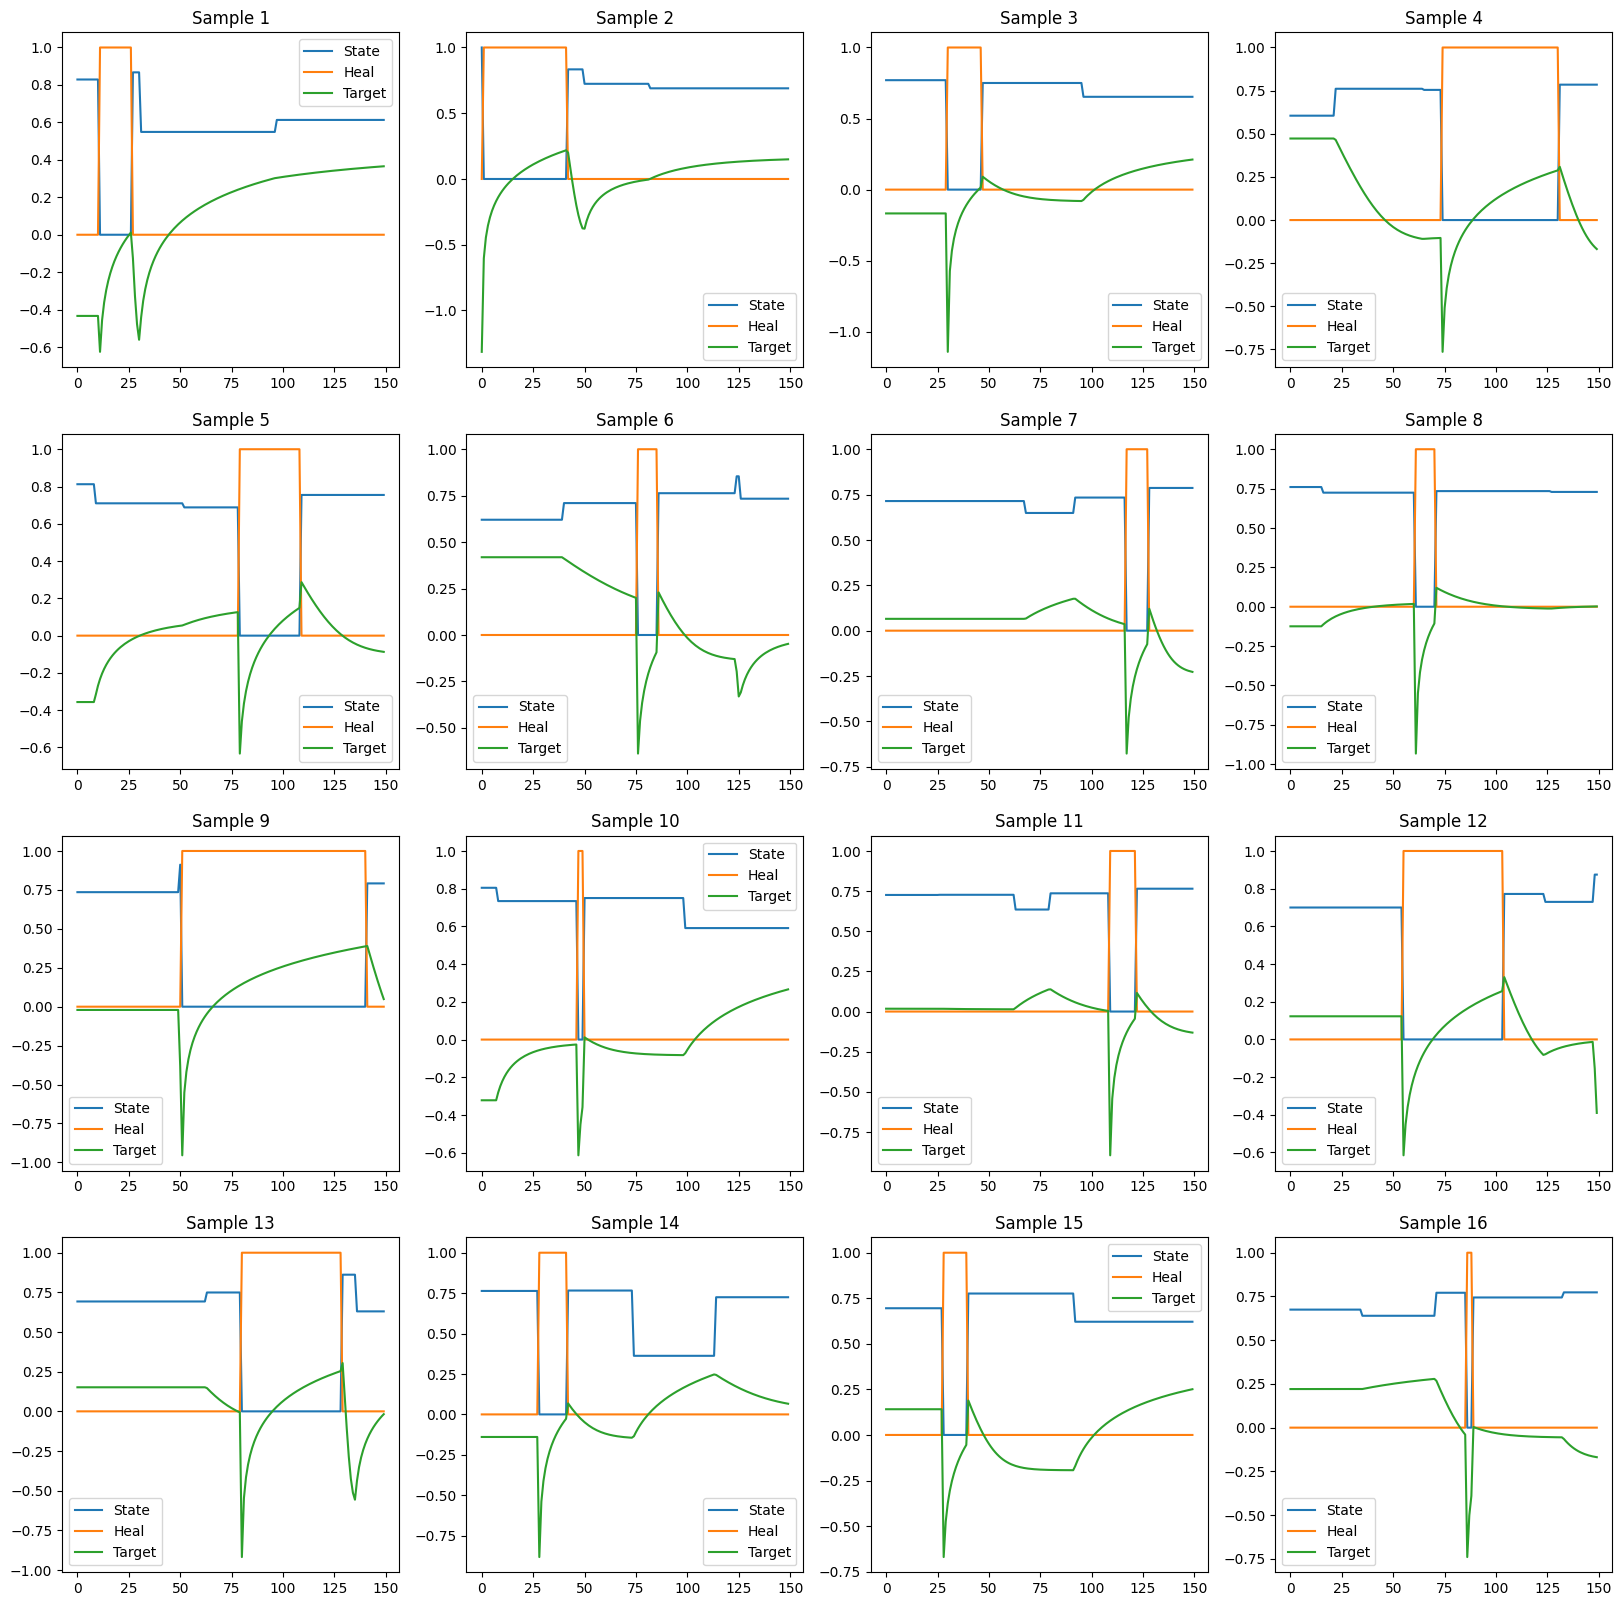

In [8]:
fig, axes = plt.subplots(4,4, figsize=(20, 20))
axes = axes.flatten()
for i in range(16):
    axes[i].plot(train_x_norm_state[i, 0, :].numpy(), label='State')
    axes[i].plot(train_x_norm_heal[i, 0, :].numpy(), label='Heal')
    axes[i].plot(train_y_norm[i, 0, :].numpy(), label='Target')
    axes[i].set_title(f"Sample {i+1}")
    axes[i].legend()

In [9]:
def init_weights(m):
    if isinstance(m, nn.Linear):
        nn.init.xavier_uniform_(m.weight)
        if m.bias is not None:
            nn.init.constant_(m.bias, 0)
    elif isinstance(m, nn.Conv1d):
        nn.init.xavier_uniform_(m.weight)
        if m.bias is not None:
            nn.init.constant_(m.bias, 0)


class SpectralConv1d(nn.Module):
    def __init__(self, 
                 in_channels : int, 
                 out_channels: int, 
                 modes: int):
        """
        Initializes a 1D spectral convolution layer using complex weights in the Fourier domain.

        Args:
            in_channels (int): Number of input channels.
            out_channels (int): Number of output channels.
            modes (int): Number of Fourier modes to retain (low-frequency modes).
        """
        super().__init__()
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.modes = modes

        scale = 1.0 / (in_channels * out_channels)
        self.real_weights = nn.Parameter(
            torch.rand(in_channels, out_channels, modes) * 2 * scale - scale
        )
        self.imag_weights = nn.Parameter(
            torch.rand(in_channels, out_channels, modes) * 2 * scale - scale
        )

    def complex_mult1d(self, x_hat, w):
        return torch.einsum("iM,ioM->oM", x_hat, w)

    def forward(self, x):
        # x: (batch, channels, spatial_points)
        batchsize, channels, spatial_points = x.shape

        x_hat = torch.fft.rfft(x, dim=-1)  # (B, C, F)
        x_hat_under_modes = x_hat[:, :, :self.modes]

        weights = torch.complex(self.real_weights, self.imag_weights)
        out_hat_under_modes = torch.einsum("bim, iom -> bom", x_hat_under_modes, weights)

        out_hat = torch.zeros(
            batchsize, self.out_channels, x_hat.shape[-1],
            dtype=torch.cfloat, device=x.device
        )
        out_hat[:, :, :self.modes] = out_hat_under_modes

        out = torch.fft.irfft(out_hat, n=spatial_points, dim=-1)
        return out


class FNOBlock1d(nn.Module):
    def __init__(self, 
                 in_channels : int, 
                 out_channels : int, 
                 modes : int, 
                 activation : nn.Module = nn.Identity(),
                 adaptive: bool = False):
        """
        Initializes a single Fourier Neural Operator (FNO) block for 1D data.

        Args:
            in_channels (int): Number of input channels.
            out_channels (int): Number of output channels.
            modes (int): Number of retained Fourier modes in the spectral convolution.
            activation (nn.Module, optional): Activation function applied after the block output. Default is nn.Identity().
        """
        
        super().__init__()
        self.activation = activation
        self.spectral_conv = SpectralConv1d(in_channels, out_channels, modes)
        self.bypass_conv = nn.Conv1d(in_channels, out_channels, kernel_size=1)

    def forward(self, x):
        sc = self.spectral_conv(x)
        bc = self.bypass_conv(x)
        out = sc + bc
        out = self.activation(out)
        return out

class Projection_NN(nn.Module):
    def __init__(self, 
                 input_dim : int, 
                 output_dim : int, 
                 width : int, 
                 depth : int, 
                 activation: nn.Module = nn.Identity()):
        
        """
        Initializes a fully-connected feedforward projection network.

        Args:
            input_dim (int): Input dimensionality.
            output_dim (int): Output dimensionality.
            width (int): Width (number of hidden units) in each hidden layer.
            depth (int): Number of layers in the network (including input/output layers).
            activation (nn.Module, optional): Activation function applied between layers. Default is nn.Identity().
        """
        
        super().__init__()

        layers = [nn.Linear(input_dim, width)]
        layers.append(activation)

        for _ in range(depth - 1):
            layers.append(nn.Linear(width, width))
            layers.append(activation)

        layers.append(nn.Linear(width, output_dim))
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        bsize, _, N = x.shape
        x = x.permute(0, 2, 1).contiguous().view(-1, self.network[0].in_features)
        x = self.network(x)
        x = x.view(bsize, N, self.network[-1].out_features).permute(0, 2, 1).contiguous()
        return x

class FNO1d(nn.Module):
    def __init__(
        self,
        in_channels : int,
        out_channels : int,
        modes : int,
        width : int,
        block_activation : nn.Module = nn.Identity(),
        n_blocks : int = 4,
        padding : int = 0,
        coord_features : bool = False,
        lift_network = None,
        decode_network = None,
    ):
        """
        Initializes a 1D Fourier Neural Operator (FNO) model.

        Args:
            in_channels (int): Number of input channels.
            out_channels (int): Number of output channels.
            modes (int): Number of Fourier modes retained in spectral convolutions.
            width (int): Width of the internal FNO layers.
            block_activation (nn.Module, optional): Activation applied after each FNO block. Default is nn.Identity().
            n_blocks (int, optional): Number of stacked FNO blocks. Default is 4.
            padding (int, optional): Amount of zero-padding added to input and removed from output. Default is 0.
            coord_features (bool, optional): Whether to append coordinate information to input. Default is False.
        """

        super().__init__()
        
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.modes = modes
        self.width = width
        self.block_activation = block_activation
        self.n_blocks = n_blocks
        self.padding = padding
        self.coord_features = coord_features
        
        self.lift_network = lift_network
        self.decode_network = decode_network

        if coord_features == True:
            self.in_channels += 1

        self.fno_blocks = nn.ModuleList([
            FNOBlock1d(width, width, modes, block_activation)
            for _ in range(n_blocks)
        ])

        self.apply(init_weights)

    # x: (B, C, N)
    def forward(self, x):

        if self.coord_features:
            bsize, size_x = x.shape[0], x.shape[2]
            grid_x = torch.linspace(0, 1, size_x, dtype=torch.float32, device=x.device)
            grid_x = grid_x.unsqueeze(0).unsqueeze(0).repeat(bsize, 1, 1)
            x = torch.cat((x, grid_x), dim=1)

        x = self.lift_network(x)

        if self.padding != 0:
            x = nn.functional.pad(x, (self.padding, self.padding), mode='constant', value=0)

        for block in self.fno_blocks:
            x = block(x)

        x = self.decode_network(x)

        if self.padding != 0:
            x = x[:, :, self.padding:-self.padding]

        return x

In [10]:
in_channels = 2
width = 32
out_channels = 1

lift_network = Projection_NN(
                input_dim = in_channels,
                output_dim = width,
                width = 64,
                depth = 2,
                activation = torch.nn.SiLU(),
            )


decode_network = Projection_NN(
                input_dim = width,
                output_dim = out_channels,
                width = 64,
                depth = 2,
                activation = torch.nn.SiLU(),
            )

model = FNO1d(
        in_channels=in_channels,
        out_channels=out_channels,
        modes=12,
        width=width,
        block_activation=torch.nn.GELU(),
        n_blocks=4,
        padding=50,
        coord_features=False,
        lift_network=lift_network,
        decode_network=decode_network,
        ).to(device)


In [11]:
def train_loop(model,
               train_loader,
               test_loader,
               epochs,
               optimizer,
               scheduler,
               clip_grad):
    
    criterion = nn.MSELoss()

    loss_history = []
    val_loss_history = []

    for epoch in range(epochs):
        model.train()
        epoch_loss = 0.0
        for batch_x, batch_y in train_loader:
            optimizer.zero_grad()
            
            output = model(batch_x.to(device))
            loss = criterion(output, batch_y.to(device))

            loss.backward()

            if clip_grad:
                utils.clip_grad_norm_(model.parameters(), 0.5)

            optimizer.step()
            epoch_loss += loss.item()
            scheduler.step()

        loss_history.append(epoch_loss / len(train_loader))
        
        model.eval()
        with torch.no_grad():
            val_loss = 0.0
            for batch_x, batch_y in test_loader:
                val_output = model(batch_x.to(device))
                val_loss += criterion(val_output, batch_y.to(device)).item()
        
        val_loss_history.append(val_loss / len(test_loader))

        print(f"EPOCH {epoch}: train_loss: {loss_history[-1]:.3e} \t test_loss: {val_loss_history[-1]:.3e}")

    return loss_history, val_loss_history

In [12]:
def make_decay_fn(factor: float, 
                  interval: int):
    return lambda step: factor ** (step // interval)

In [13]:
lr = 1e-3
optimizer = optim.Adam(model.parameters(), lr=lr)
scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda= make_decay_fn(0.995, 1000))

loss_history, val_loss_history = [], []
loss_history, val_loss_history = train_loop(model, train_loader, test_loader,
                                            300, optimizer, scheduler, False)

EPOCH 0: train_loss: 3.445e-02 	 test_loss: 2.891e-02
EPOCH 1: train_loss: 2.943e-02 	 test_loss: 2.441e-02
EPOCH 2: train_loss: 2.595e-02 	 test_loss: 2.147e-02
EPOCH 3: train_loss: 2.325e-02 	 test_loss: 1.938e-02
EPOCH 4: train_loss: 2.089e-02 	 test_loss: 1.706e-02
EPOCH 5: train_loss: 1.868e-02 	 test_loss: 1.535e-02
EPOCH 6: train_loss: 1.615e-02 	 test_loss: 1.207e-02
EPOCH 7: train_loss: 1.267e-02 	 test_loss: 9.659e-03
EPOCH 8: train_loss: 1.004e-02 	 test_loss: 8.422e-03
EPOCH 9: train_loss: 9.265e-03 	 test_loss: 7.335e-03
EPOCH 10: train_loss: 8.018e-03 	 test_loss: 7.604e-03
EPOCH 11: train_loss: 7.549e-03 	 test_loss: 6.865e-03
EPOCH 12: train_loss: 7.012e-03 	 test_loss: 5.782e-03
EPOCH 13: train_loss: 6.301e-03 	 test_loss: 5.544e-03
EPOCH 14: train_loss: 6.022e-03 	 test_loss: 5.574e-03
EPOCH 15: train_loss: 5.874e-03 	 test_loss: 4.880e-03
EPOCH 16: train_loss: 5.394e-03 	 test_loss: 4.818e-03
EPOCH 17: train_loss: 5.077e-03 	 test_loss: 4.563e-03
EPOCH 18: train_loss

KeyboardInterrupt: 

In [14]:
def plot_results(model, x, y, name):

    fig, axes = plt.subplots(4, 4, figsize=(10, 10))
    axes = axes.flatten()
    for i in range(16):
        pred = model(x[i:i+1])[0].cpu().detach().numpy()
        ax1 = axes[i]

        ax1.plot(y[i, 0, :].cpu().detach().numpy(), color='tab:orange', label='Ground Truth' if i == 0 else "")
        ax1.plot(pred[0], color='tab:green', label='Prediction' if i == 0 else "")
        ax1.set_xticks([])
        ax1.set_yticks([])

    fig.suptitle(name, fontsize=22, y=0.98)

    fig.legend(loc='upper center', bbox_to_anchor=(0.5, 0.95), ncol=2, fontsize=16)

    plt.tight_layout(rect=[0, 0, 1, 0.95])  
    plt.show()

def plot_loss(loss, val):

    fig, ax = plt.subplots(figsize=(8, 6))
    ax.plot(loss, label="train loss")
    ax.plot(val, label="val loss")
    ax.legend(fontsize=14)
    ax.set_yscale("log")
    ax.grid(True)
    ax.tick_params(axis='both', which='major', labelsize=14)
    fig.suptitle("Loss History", fontsize=18)
    plt.tight_layout()
    plt.show()

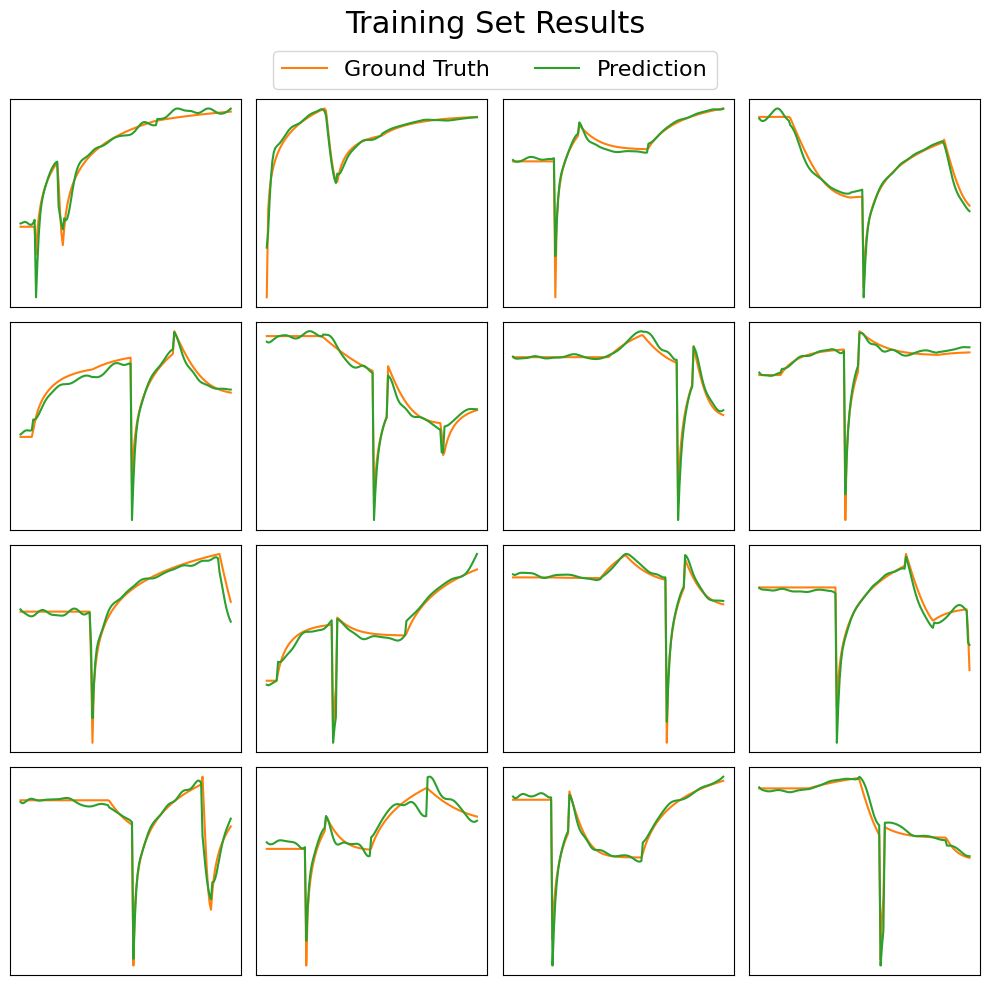

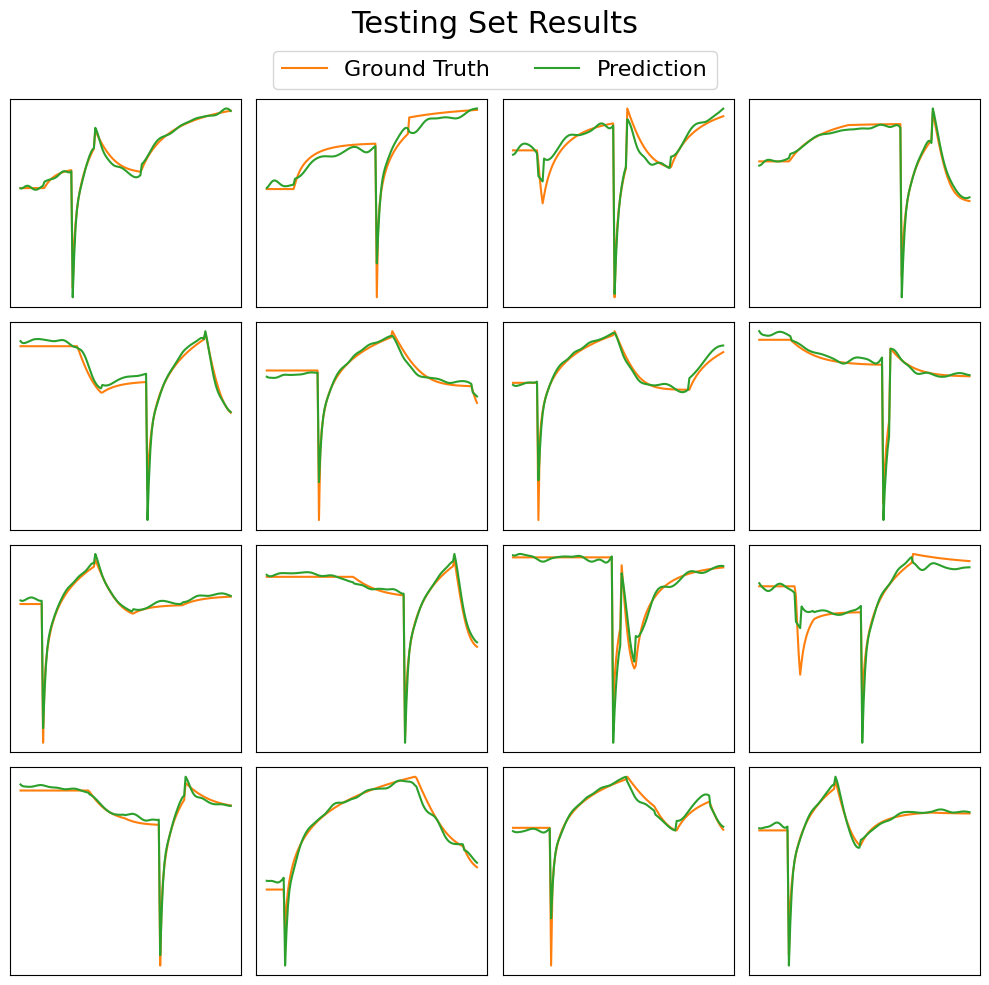

In [ ]:
plot_loss(loss_history, val_loss_history)
plot_results(model, train_x_norm, train_y_norm, "Training Set Results")
plot_results(model, test_x_norm, test_y_norm, "Testing Set Results")